<a href="https://colab.research.google.com/github/gav-ip/ML-zero/blob/main/makemore_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
print(words[:8])
print(len(words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
32033


In [4]:
# build mapping of the vocab of string to integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# bulid dataset

block_size = 3 # context length: how many chars do we need to predict another one?

X, Y = [], []
for w in words:

  # print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context),'--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

small notes:\
like in E04 of the first lecture video where it asks us to replace the one_hot encoding function call we can instead just indrectly index the rows of a matrix

In [7]:
# EX: C is our look up table (embedding) for each character
C = torch.randn(27,2)


In [8]:
C[5]

tensor([0.9847, 0.5844])

In [9]:
# we can also index on multiple rows of C by using a list

C[[5,6,7]]

tensor([[ 0.9847,  0.5844],
        [ 0.8189, -0.4791],
        [-0.5111,  0.7026]])

In [10]:
# or index using a tensor
C [torch.tensor([5,6,7])]

tensor([[ 0.9847,  0.5844],
        [ 0.8189, -0.4791],
        [-0.5111,  0.7026]])

In [11]:
C[X].shape

torch.Size([228146, 3, 2])

In [12]:
X[13,2]

tensor(1)

In [13]:
C[1]

tensor([-0.8179,  0.4000])

In [14]:
C[X][13,2]

tensor([-0.8179,  0.4000])

creating our input layer

In [15]:
# our embedding matrix
emb = C[X]
emb.shape # (96 x 2 layers)

torch.Size([228146, 3, 2])

In [16]:
# number of inputs is 3 * 2 = 6
# 3 dimensional embeddings (block_size)
# 2 (2 columns for the size of C )
W1 = torch.randn(6,100)
b1 = torch.randn(100)

In [17]:
# notice how we can't mat mul the emb matrix due to a dimensionality difference
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (684438x2 and 6x100)

In [18]:
# indexing each block size
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([228146, 6])

In [19]:
# can also use torch unbind
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([228146, 6])

In [33]:
# recommended: using torch.view(), exteremely efficient, no memory is being changed, copied,or removed.
# emb.view(32, 6).shape

hidden layer implementation

In [21]:
# hidden layer activation for all 32 examples
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)
# alternatively we can do: torch.tanh(emb.view(-1, 6) @ W1 + b1), pytorch will derive that -1 is 32 (or m size of a matrix)

creating the output layer

In [22]:
# weight and biases
W2 = torch.randn(100,27)
b2 = torch.randn(27)

In [23]:
logits = h @ W2 + b2

In [24]:
# same procedure as doing cross entropy to going into the softmax layer
counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
probs.shape

torch.Size([228146, 27])

we can clean this up and organize all the params and operations to calculate the loss

In [25]:
# dataset shape
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [39]:
# bulid dataset
def build_dataset(words):

  block_size = 3 # context length: how many chars do we need to predict another one?
  X, Y = [], []
  for w in words:

    # print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      # print(''.join(itos[i] for i in context),'--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [62]:
# params
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [51]:
sum(p.nelement() for p in parameters) # num of total params in our NN

3481

In [63]:
for p in parameters:
  p.requires_grad = True

In [64]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
# lrs

In [65]:
lri = []
lossi = []
stepi = []
for i in range(30000):


  # minibatch construct
  # NOTE: thibs decreases the grad descenet much faster due to indexing many examples
  # instantly instead of the doing a backwards pass every iteration on the entire dataset
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3 ,2)
  h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  # print(loss.item())

  # backward pass

  # counts = logits.exp()
  # probs = counts / counts.sum(1, keepdim=True)
  # loss = -probs[torch.arange(32), Y].log().mean()

  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  # lr = lrs[i]
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.item())

# print(loss.item())

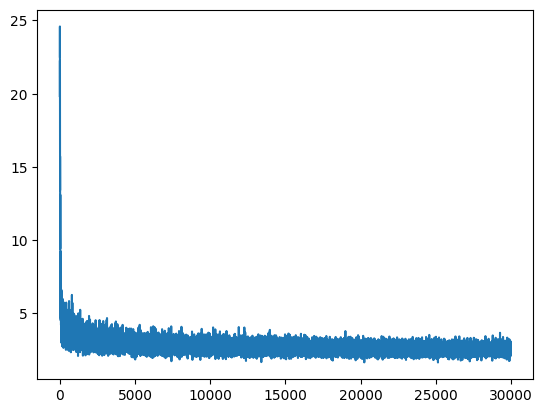

In [66]:
plt.plot(stepi, lossi)

In [56]:
emb = C[Xdev] # (32, 3 ,2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.3835, grad_fn=<NllLossBackward0>)

In [57]:
emb = C[Xtr] # (32, 3 ,2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.3855, grad_fn=<NllLossBackward0>)

bulid dataset split (80/20/10)\
prevents overfitting and helps improve generalization